In [3]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import dask.dataframe as dd

from src.data_preprocessing import load_and_prepare_data

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from sktime.utils.plotting import plot_series
from sktime.split import TemporalTrainTestSplitter
from sktime.transformations.series.detrend import STLTransformer

# hide warnings
warnings.filterwarnings("ignore")

ModuleNotFoundError: No module named 'src'

## Importing the dataset

In [4]:
df = load_and_prepare_data("data/raw/GlobalTemperatures.csv")
df.head()

,LandAverageTemperature,LandAverageTemperatureUncertainty
dt,,
1750-01-01,3.034,3.574
1750-02-01,3.083,3.702
1750-03-01,5.626,3.076
1750-04-01,8.490,2.451
1750-05-01,11.573,2.072


## Handling missing values

In [5]:
missing_values = df.isnull().sum()
missing_values

LandAverageTemperature               12
LandAverageTemperatureUncertainty    12
dtype: int64

In [6]:
rows_with_missing = df[df.isnull().any(axis=1)]
rows_with_missing

,LandAverageTemperature,LandAverageTemperatureUncertainty
dt,,
1750-11-01,NaN,NaN
1751-05-01,NaN,NaN
1751-07-01,NaN,NaN
1751-10-01,NaN,NaN
1751-11-01,NaN,NaN
1751-12-01,NaN,NaN
1752-02-01,NaN,NaN
1752-05-01,NaN,NaN
1752-06-01,NaN,NaN


For simplicity we will only consider the values from 1800 also because they have a much lower uncertainity

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='LandAverageTemperatureUncertainty'>)

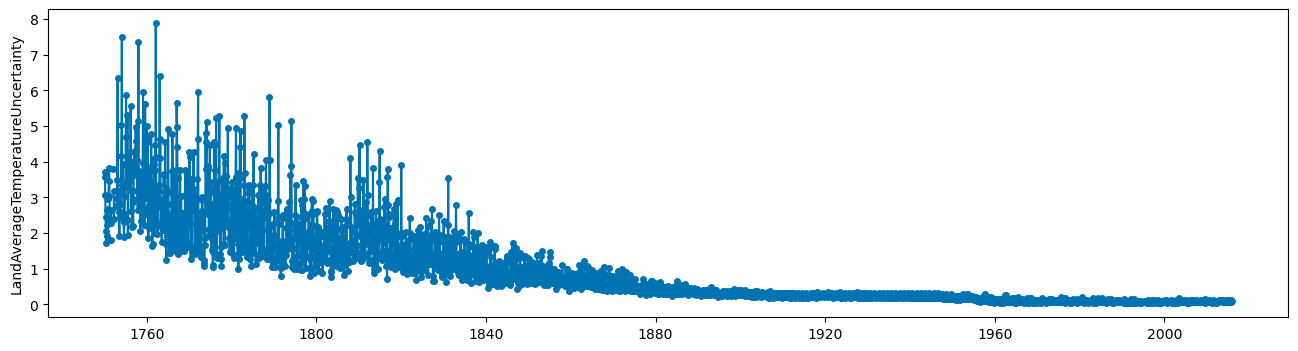

In [7]:
plot_series(df["LandAverageTemperatureUncertainty"])


In [8]:
df_filtered = df[df.index.year > 1800]
df_filtered

,LandAverageTemperature,LandAverageTemperatureUncertainty
1801-01-01,2.687,1.922
1801-02-01,3.149,2.045
1801-03-01,6.455,1.336
1801-04-01,7.404,1.619
1801-05-01,12.123,1.541
...,...,...
2015-08-01,14.755,0.072
2015-09-01,12.999,0.079
2015-10-01,10.801,0.102
2015-11-01,7.433,0.119


## Splitting the dataset into train and test


In [9]:
splitter = TemporalTrainTestSplitter(test_size=0.2)
train_indices, test_indices = next(splitter.split(df_filtered["LandAverageTemperature"]))
df_filtered_train = df_filtered.iloc[train_indices]
df_filtered_test = df_filtered.iloc[test_indices]

In [22]:
df_filtered_test

,LandAverageTemperature,LandAverageTemperatureUncertainty
1973-01-01,3.038,0.092
1973-02-01,3.898,0.161
1973-03-01,5.820,0.096
1973-04-01,8.938,0.103
1973-05-01,11.769,0.082
...,...,...
2015-08-01,14.755,0.072
2015-09-01,12.999,0.079
2015-10-01,10.801,0.102
2015-11-01,7.433,0.119


In [23]:
df_filtered_train

,LandAverageTemperature,LandAverageTemperatureUncertainty
1801-01-01,2.687,1.922
1801-02-01,3.149,2.045
1801-03-01,6.455,1.336
1801-04-01,7.404,1.619
1801-05-01,12.123,1.541
...,...,...
1972-08-01,14.171,0.096
1972-09-01,11.901,0.126
1972-10-01,9.346,0.141
1972-11-01,5.797,0.079


## Plots

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='LandAverageTemperature'>)

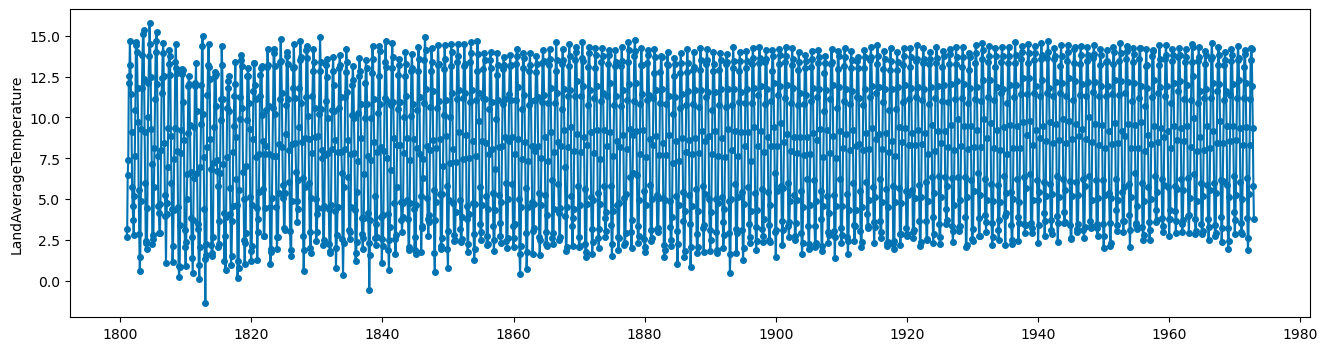

In [24]:
# Timeplot
plot_series(df_filtered_train["LandAverageTemperature"])

The time plot shows strong seasonality, with repeated, cyclical up-and-down patterns throughout the entire time range. These cyclical variations are likely related to seasonal temperature changes, which is expected because Earth's land is not distributed symmetrically around the equator. Regarding the trend, there does not appear to be a clear overall increase or decrease in temperature between 1800 and 1980. The temperature values oscillate within a relatively stable range, suggesting that during this period, global land average temperatures did not experience any significant upward or downward shifts. However, there is significant variability that may resemble white noise.
Also there are not many outliers.

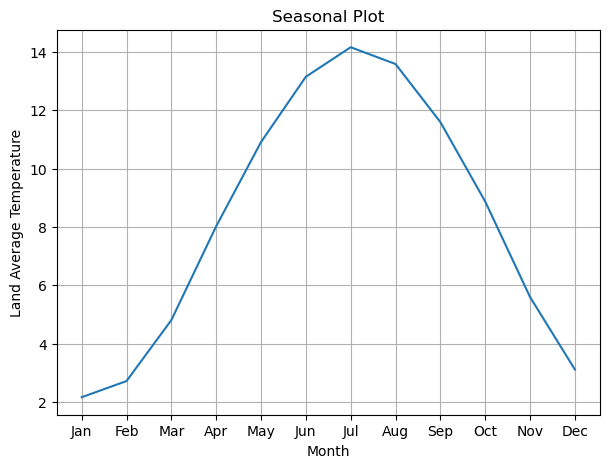

In [27]:
# Seasonal plot 

plt.figure(figsize=(7, 5)) 
sns.lineplot(x=df_filtered_train.index.month, y=df_filtered_train['LandAverageTemperature'], ci=None) 
plt.xlabel('Month') 
plt.ylabel('Land Average Temperature') 
plt.title('Seasonal Plot') 
plt.xticks(range(1, 13), labels=[ 
           'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']) 
plt.grid(True) 
plt.show() 

The graph above clearly depicts a seasonal pattern, as expected for temperature data. The temperatures during the winter months (December to February) are significantly lower compared to the summer months (June to August), where temperatures peak.

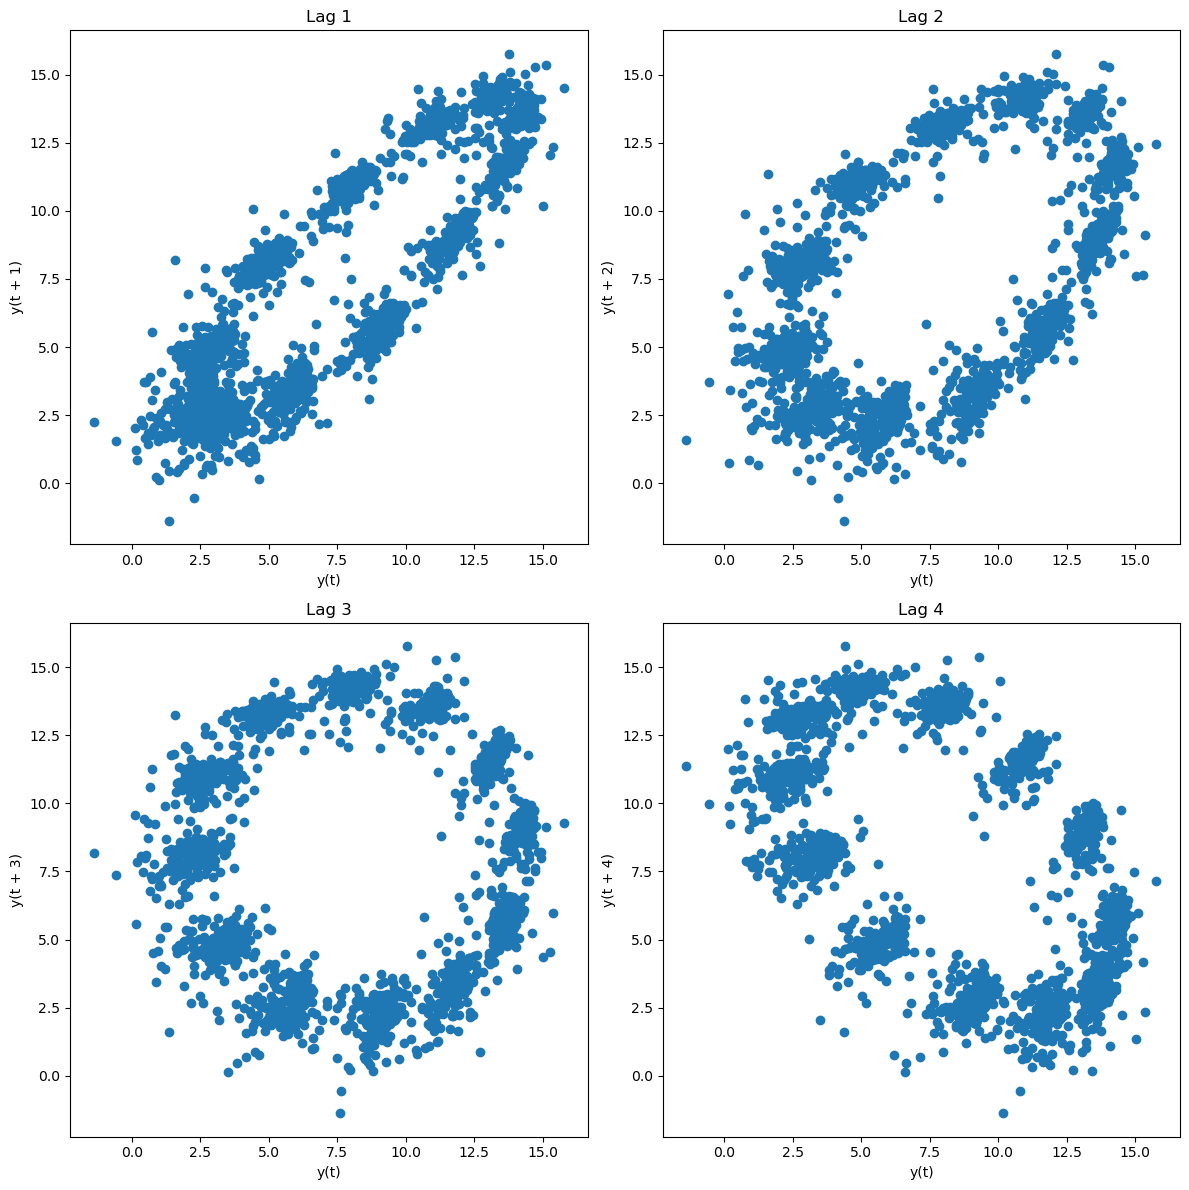

In [34]:
# Lag plot
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

pd.plotting.lag_plot(df_filtered_train["LandAverageTemperature"], lag=1, ax=axes[0, 0])
axes[0, 0].set_title('Lag 1')

pd.plotting.lag_plot(df_filtered_train["LandAverageTemperature"], lag=2, ax=axes[0, 1])
axes[0, 1].set_title('Lag 2')

pd.plotting.lag_plot(df_filtered_train["LandAverageTemperature"], lag=3, ax=axes[1, 0])
axes[1, 0].set_title('Lag 3')

pd.plotting.lag_plot(df_filtered_train["LandAverageTemperature"], lag=4, ax=axes[1, 1])
axes[1, 1].set_title('Lag 4')

plt.tight_layout()
plt.show()


The lag plots reveal that the temperature series has a strong autocorrelation at small lags (e.g., lag 1) and a cyclical structure at higher lags (lag 2, 3, 4). This is consistent with time series data that exhibits seasonality, where values repeat in regular intervals.

<Figure size 700x500 with 0 Axes>

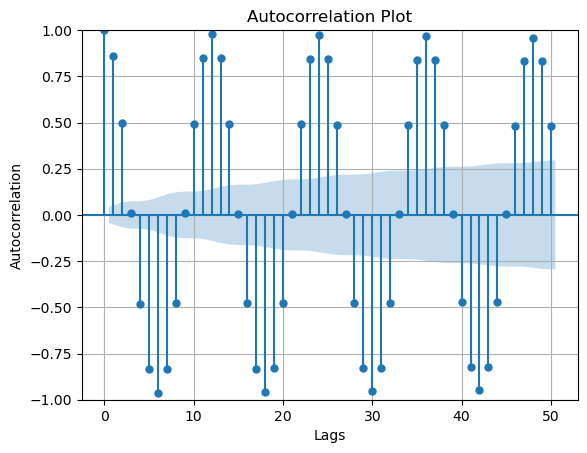

In [40]:
# ACF
plt.figure(figsize=(7,5)) 
plot_acf(df_filtered_train["LandAverageTemperature"], lags=50) 
plt.xlabel('Lags') 
plt.ylabel('Autocorrelation') 
plt.title('Autocorrelation Plot') 
plt.grid(True) 
plt.show()

The ACF plot suggests that the time series has strong periodicity and seasonality, as seen from the repeating cycles of positive and negative autocorrelation.

<Figure size 700x500 with 0 Axes>

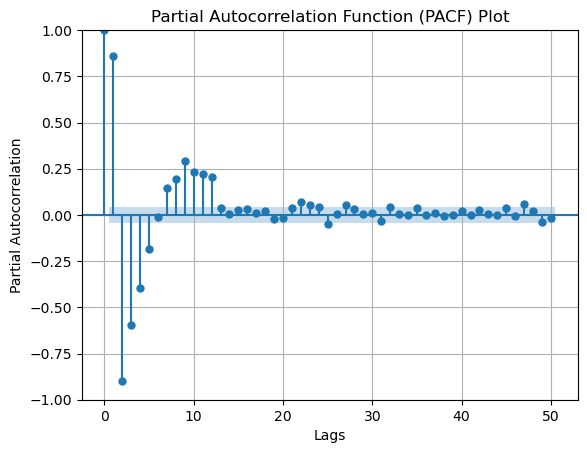

In [42]:
# PACF plot 
plt.figure(figsize=(7, 5)) 
plot_pacf(df_filtered_train["LandAverageTemperature"], lags=50) 
plt.xlabel('Lags') 
plt.ylabel('Partial Autocorrelation') 
plt.title('Partial Autocorrelation Function (PACF) Plot') 
plt.grid(True) 
plt.show() 


The PACF plot shows significant partial autocorrelations up to lag 6, indicating a potential autoregressive (AR) process with around 6 lags.

## STL Decomposition

In [17]:
transformer = STLTransformer(sp=12)
Xt = transformer.fit_transform(df_filtered_train["LandAverageTemperature"])

In [12]:
Xt.head()

1801-01-01    8.485837
1801-02-01    8.856035
1801-03-01    9.114271
1801-04-01    8.413725
1801-05-01    9.169173
Name: LandAverageTemperature, dtype: float64

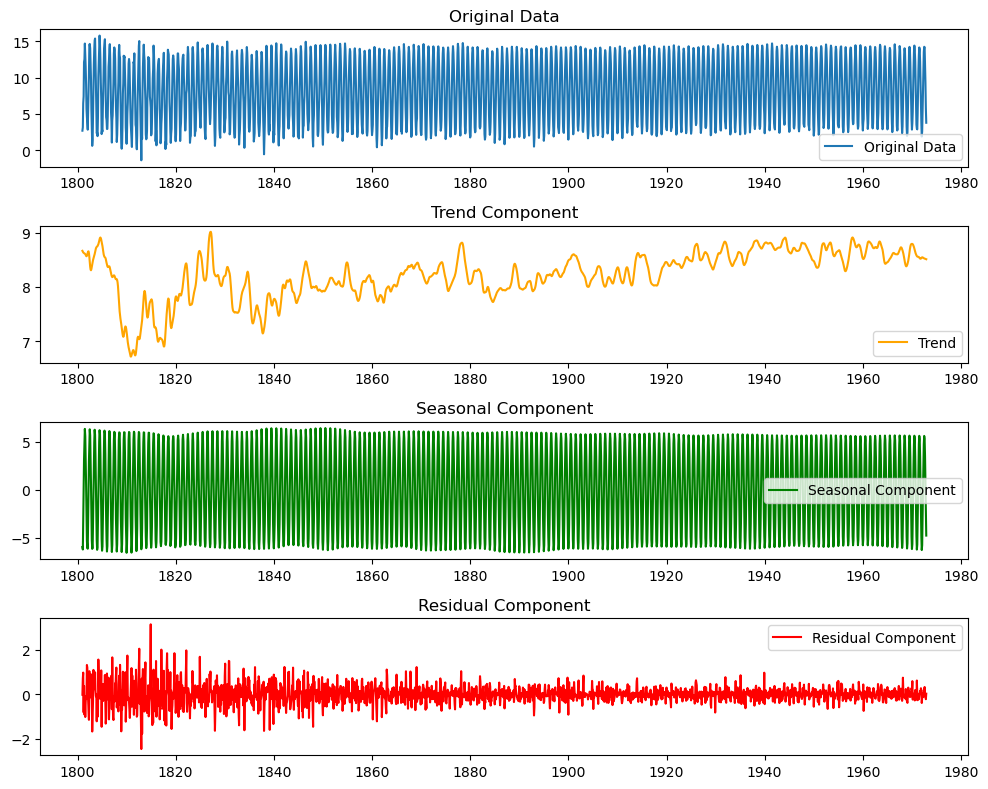

In [15]:
# StatsModel
stl = STL(df_filtered_train["LandAverageTemperature"], seasonal=13)  # 12 months + 1 for better smoothing
result = stl.fit()

# Extracting the components
trend = result.trend
seasonal = result.seasonal
residual = result.resid

# Plotting the original data, trend, seasonal, and residual components
plt.figure(figsize=(10, 8))

plt.subplot(4, 1, 1)
plt.plot(df_filtered_train["LandAverageTemperature"], label='Original Data')
plt.title('Original Data')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend', color='orange')
plt.title('Trend Component')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(seasonal, label='Seasonal Component', color='green')
plt.title('Seasonal Component')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residual Component', color='red')
plt.title('Residual Component')
plt.legend()

plt.tight_layout()
plt.show()


- Original Data: The first plot shows the raw land average temperature data. You can clearly see the repeating seasonal pattern in the data.

- Trend Component: The second plot shows the long-term trend in the temperature data. It looks like there was a decline in the early 1800s, followed by a gradual increase in temperature, particularly after the mid-1800s.

- Seasonal Component: The third plot displays the seasonal fluctuations, which represent the cyclical pattern that repeats every year. This is the periodic variation in temperature that reflects the changes in climate throughout the year. The seasonal pattern is relatively stable over time.

- Residual Component: The final plot shows the residual, which represents the noise or unexplained variation after removing the trend and seasonal components. In this case, the residuals appear to become smaller over time, suggesting that the seasonal and trend components explain more of the variance in the later part of the series compared to the earlier part.